__If you are new to PheTK, please check out the APOE PheWAS - Logistic Regression notebook first.__

This notebook demonstrates how to run the same PheWAS pipeline in using dsub to schedule job on Google Cloud.

__Is there any advantage running PheTK using dsub compared to running directly in the notebook environment?__ 

_Yes, there are many advantages, including being able to select new computing hardware (vs stuck with default hardware in the notebook), being able to scale up for large scale analyses (think hundreds or thousands of PheWAS runs or more), etc._

Often, users would run dsub once they already have a working pipeline and already familiar with PheTK. While PheTK simplifies how to run PheWAS with dsub, users should learn to understand what happens behind the scene after a dsub job is submitted, how to monitor the jobs and how to potentially troubleshoot when there is any issue.

In this notebook, we will run PheWAS with dsub using PheTK for the same workflow in the Logistic Regression notebook, except that PheWAS analysis will be run using dsub.

## Initial setup

In [1]:
!pip install --upgrade \
--index-url https://test.pypi.org/simple/ \
--extra-index-url https://pypi.org/simple/ \
phetk==0.2.1rc132

Looking in indexes: https://test.pypi.org/simple/, https://pypi.org/simple/
  Using cached https://test-files.pythonhosted.org/packages/d5/c1/f27dfa63fa0e59bb5a186e3c12551a1e2f2c2cbce01bfc20b604962d985f/phetk-0.2.1rc132-py3-none-any.whl.metadata (7.4 kB)


Using cached https://test-files.pythonhosted.org/packages/d5/c1/f27dfa63fa0e59bb5a186e3c12551a1e2f2c2cbce01bfc20b604962d985f/phetk-0.2.1rc132-py3-none-any.whl (1.4 MB)
  Attempting uninstall: phetk
    Found existing installation: phetk 0.2.1rc130
    Uninstalling phetk-0.2.1rc130:
      Successfully uninstalled phetk-0.2.1rc130
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
!pip show PheTK | grep Version

Version: 0.2.1rc132


__Please restart the notebook kernel before proceeding to the next step.__

In [1]:
from phetk.cohort import Cohort
from phetk.phecode import Phecode
from phetk.phewas import PheWAS
from phetk.plot import Plot

import os

In [2]:
bucket = os.getenv("WORKSPACE_BUCKET")

## Preparing inputs for PheWAS with dsub

Note: since dsub requires inputs and outputs to be in a Google Cloud bucket, all the steps below will utilize Google Cloud bucket where applicable instead of local notebook storage.

For simplicity, the CLI version will be used to generate cohort, add covariates, and generate phecode counts, which will be used as input in PheWAS. All files will be saved in a bucket.

Here All of Us already created an environment variable named WORKSPACE_BUCKET storing the bucket address. We will use it and add some folder path after as desired.

In [8]:
%%bash -s "$bucket"
# exit script if a command fails
set -e

# add phetk path
export PATH=$PATH:/home/jupyter/.local/bin

# create cohort
echo "Creating cohort..."
echo
phetk cohort by-genotype \
--platform aou \
--aou_db_version 8 \
--chromosome_number 19 \
--genomic_position=44908684 \
--ref_allele T \
--alt_allele C \
--gt_dict '{"0": "0/0", "1":["0/1", "1/1"]}' \
--output_file_path "${WORKSPACE_BUCKET}/test/data/dsub__rs429358_cohort.tsv"

# add covariates
echo "Adding covariates..."
echo
phetk cohort add-covariates \
--cohort_file_path "${WORKSPACE_BUCKET}/test/data/dsub__rs429358_cohort.tsv" \
--age_at_last_ehr_event true \
--sex_at_birth true \
--first_n_pcs 5 \
--drop_nulls true \
--output_file_path "${WORKSPACE_BUCKET}/test/data/dsub__rs429358_cohort_with_covariates.tsv"

# generate phecode counts
echo "Generating phecode counts..."
echo
phetk phecode count-phecode \
--platform aou \
--phecode_version X \
--output_file_path "${WORKSPACE_BUCKET}/test/data/dsub__aou_phecode_counts.tsv"


Creating cohort...



/opt/conda/lib/python3.10/site-packages/hail/context.py:350: UserWarning: Using hl.init with a default_reference argument is deprecated. To set a default reference genome after initializing hail, call `hl.default_reference` with an argument to set the default reference genome.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/hailtop/aiocloud/aiogoogle/user_config.py:43: UserWarning: Reading spark-defaults.conf to determine GCS requester pays configuration. This is deprecated. Please use `hailctl config set gcs_requester_pays/project` and `hailctl config set gcs_requester_pays/buckets`.
  warnings.warn(
Running on Apache Spark version 3.5.3
SparkUI available at http://all-of-us-5797-m.us-central1-c.c.terra-vpc-sc-7883f2cd.internal:44649
Welcome to
     __  __     <>__
    / /_/ /__  __/ /
   / __  / _ `/ / /
  /_/ /_/\_,_/_/_/   version 0.2.134-952ae203dbbe
LOGGING: writing to /home/jupyter/workspaces/phetkv8/hail-20250730-0243-0.2.134-952ae203dbbe.log
2025-07-30 02:44:17.702 Ha


Locus chr19:44908684 found!
+----------------+------------+----------+---------+-----------+
| locus          | alleles    | filters  | a_index | was_split |
+----------------+------------+----------+---------+-----------+
| locus<GRCh38>  | array<str> | set<str> |   int32 |      bool |
+----------------+------------+----------+---------+-----------+
| chr19:44908684 | ["T","C"]  | {}       |       1 |     False |
+----------------+------------+----------+---------+-----------+

+--------------------------+---------------------------+
| variant_qc.gq_stats.mean | variant_qc.gq_stats.stdev |
+--------------------------+---------------------------+
|                  float64 |                   float64 |
+--------------------------+---------------------------+
|                 4.30e+01 |                  8.93e+00 |
+--------------------------+---------------------------+

+-------------------------+-------------------------+----------------------+
| variant_qc.gq_stats.min | variant_qc

100%|██████████| 42/42 [02:32<00:00,  3.62s/it]



Cohort size: 280444 participants
Genotype 0: 204525 participants
Genotype 1: 75919 participants

Cohort data saved as "gs://fc-secure-a52e0406-9775-41b6-b56f-f0c5dc653c72/test/data/dsub__rs429358_cohort_with_covariates.tsv"!

Generating phecode counts...

Start querying ICD codes...
Done!

Mapping ICD codes to phecodeX...
Successfully generated phecodeX counts for cohort participants!

Saved to gs://fc-secure-a52e0406-9775-41b6-b56f-f0c5dc653c72/test/data/dsub__aou_phecode_counts.tsv



## PheWAS with PheTK using dsub

In [10]:
# instantiate class PheWAS the same way as running in notebook, note that we need use the files in the bucket instead
phewas = PheWAS(
    phecode_version="X",
    phecode_count_file_path=f"{bucket}/test/data/dsub__aou_phecode_counts.tsv",
    cohort_file_path=f"{bucket}/test/data/dsub__rs429358_cohort_with_covariates.tsv",
    sex_at_birth_col="sex_at_birth",
    male_as_one=True,
    covariate_cols=[
        "age_at_last_ehr_event", "sex_at_birth",
        "pc1", "pc2", "pc3", "pc4", "pc5"
    ],
    independent_variable_of_interest="genotype",
    min_cases=50,
    min_phecode_count=2,
    method="logit",
    output_file_path=f"{bucket}/test/results/dsub__rs429358_phewas_results.tsv"
)

# run PheWAS using dsub
phewas.run_dsub(
    docker_image="phetk/phetk:0.2.1rc132p",
    machine_type="c2d-standard-16"
)

~~~~~~~~~~~~~~~~~~~~~~~~~    Creating PheWAS Object    ~~~~~~~~~~~~~~~~~~~~~~~~~

Cohort size:  280444
genotype descriptions:  shape: (2, 2)
┌──────────┬────────┐
│ genotype ┆ count  │
│ ---      ┆ ---    │
│ i64      ┆ u32    │
╞══════════╪════════╡
│ 0        ┆ 204525 │
│ 1        ┆ 75919  │
└──────────┴────────┘

Number of unique phecodes in cohort:  3430
Total number of phecode events:  20812932
Number of phecode batches to process:  3430

Analysis method:  Logistic regression

~~~~~~~~~~~~~~~~~~~~~~~~~~~~    Setting up dsub    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Generated script: phewas_script.sh

PheWAS script content:
#!/bin/bash
phetk phewas --phecode_version X --phecode_count_file_path $PHECODE_COUNT_FILE_PATH --cohort_file_path $COHORT_FILE_PATH --covariate_cols age_at_last_ehr_event sex_at_birth pc1 pc2 pc3 pc4 pc5 --independent_variable_of_interest genotype --sex_at_birth_col sex_at_birth --male_as_one True --output_file_path $OUTPUT_FILE_PATH --min_cases 50 --min_phecode_count 

## Monitoring dsub job

In [12]:
phewas.dsub.check_status(streaming=True)

                                                                                
[02:58:30] Job Status: RUNNING
Job Name         Status                                      Last Update
---------------  ------------------------------------------  --------------
phewas-20250...  Job state is set from QUEUED to SCHEDUL...  07-30 02:58:25

                                                                                
[03:03:40] Job Status: RUNNING
Job Name         Status                                      Last Update
---------------  ------------------------------------------  --------------
phewas-20250...  Job state is set from SCHEDULED to RUNN...  07-30 03:03:01

                                                                                
[03:27:23] Job Status: SUCCESS
Job Name         Status                                      Last Update
---------------  ------------------------------------------  --------------
phewas-20250...  Job state is set from RUNNING to SUCCEE...  07

As you could see, the same 16 CPU machine but with newer CPU generation (c2d vs n1 or similar for default in the workbench) it took 24 minutes from RUNNING to SUCCEED, while it took 37 minutes in the notebook example. The cost for c2d machines and n1 machines are very close for similar settings making this a much more cost efficient way to run PheWAS.

### Caution with Google Batch

Since 08 July 2025, Google stop using gls and started using Google Batch. Since then, dsub has not been fully functional, e.g., boot disk type cannot be set leading to newer machine generations could not be used. Here it was also observed that dsub job might still exist after the actualy job (PheWAS) completed successfully. 

While these could be the remaining metadata for the run, it is recommended that users would run the `view_all()` and `kill_all()` functions below after a successful run to make sure it completely stopped.

In [36]:
print(datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
phewas.dsub.view_all()

2025-07-30 03:50:44
Job Name         Status                                      Last Update
---------------  ------------------------------------------  --------------
phewas-20250...  Job state is set from RUNNING to SUCCEE...  07-30 03:27:01



In [37]:
print(datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
phewas.dsub.kill_all()

2025-07-30 03:51:03


Delete running jobs:
  user:
    {'tam-tran'}

  job-id:
    ['*']

Found 1 tasks to delete.


1 job deleted


## View stdout/stderr

In [39]:
# Users can check the output of the run as below:
phewas.dsub.view_log(log_type="stdout", n_lines=100)

~~~~~~~~~~~~~~~~~~~~~~~~~    Creating PheWAS Object    ~~~~~~~~~~~~~~~~~~~~~~~~~

Cohort size:  280444
genotype descriptions:  shape: (2, 2)
┌──────────┬────────┐
│ genotype ┆ count  │
│ ---      ┆ ---    │
│ i64      ┆ u32    │
╞══════════╪════════╡
│ 1        ┆ 75919  │
│ 0        ┆ 204525 │
└──────────┴────────┘

Number of unique phecodes in cohort:  3430
Total number of phecode events:  20812932
Number of phecode batches to process:  3430

Analysis method:  Logistic regression

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~    Running PheWAS    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Parallelization method: multithreading
Number of workers: 11

Creating ThreadPoolExecutor...
Submitting jobs to workers...
Submitted 3430 jobs. Running regressions...
Multithreading completed successfully.
Combining 2517 result files...
Concatenating results...
Cleaning up temporary files...

~~~~~~~~~~~~~~~~~~~~~~~~~~~~    PheWAS Completed    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Number of participants in cohort: 280444
Number of phec

In [38]:
# If there was any error, the log below should contain some error details:
phewas.dsub.view_log(log_type="stderr", n_lines=100)

## Result visualization

In [16]:
# instantiate class Plot with PheWAS results as input
p = Plot(f"{bucket}/test/results/dsub__rs429358_phewas_results.tsv")

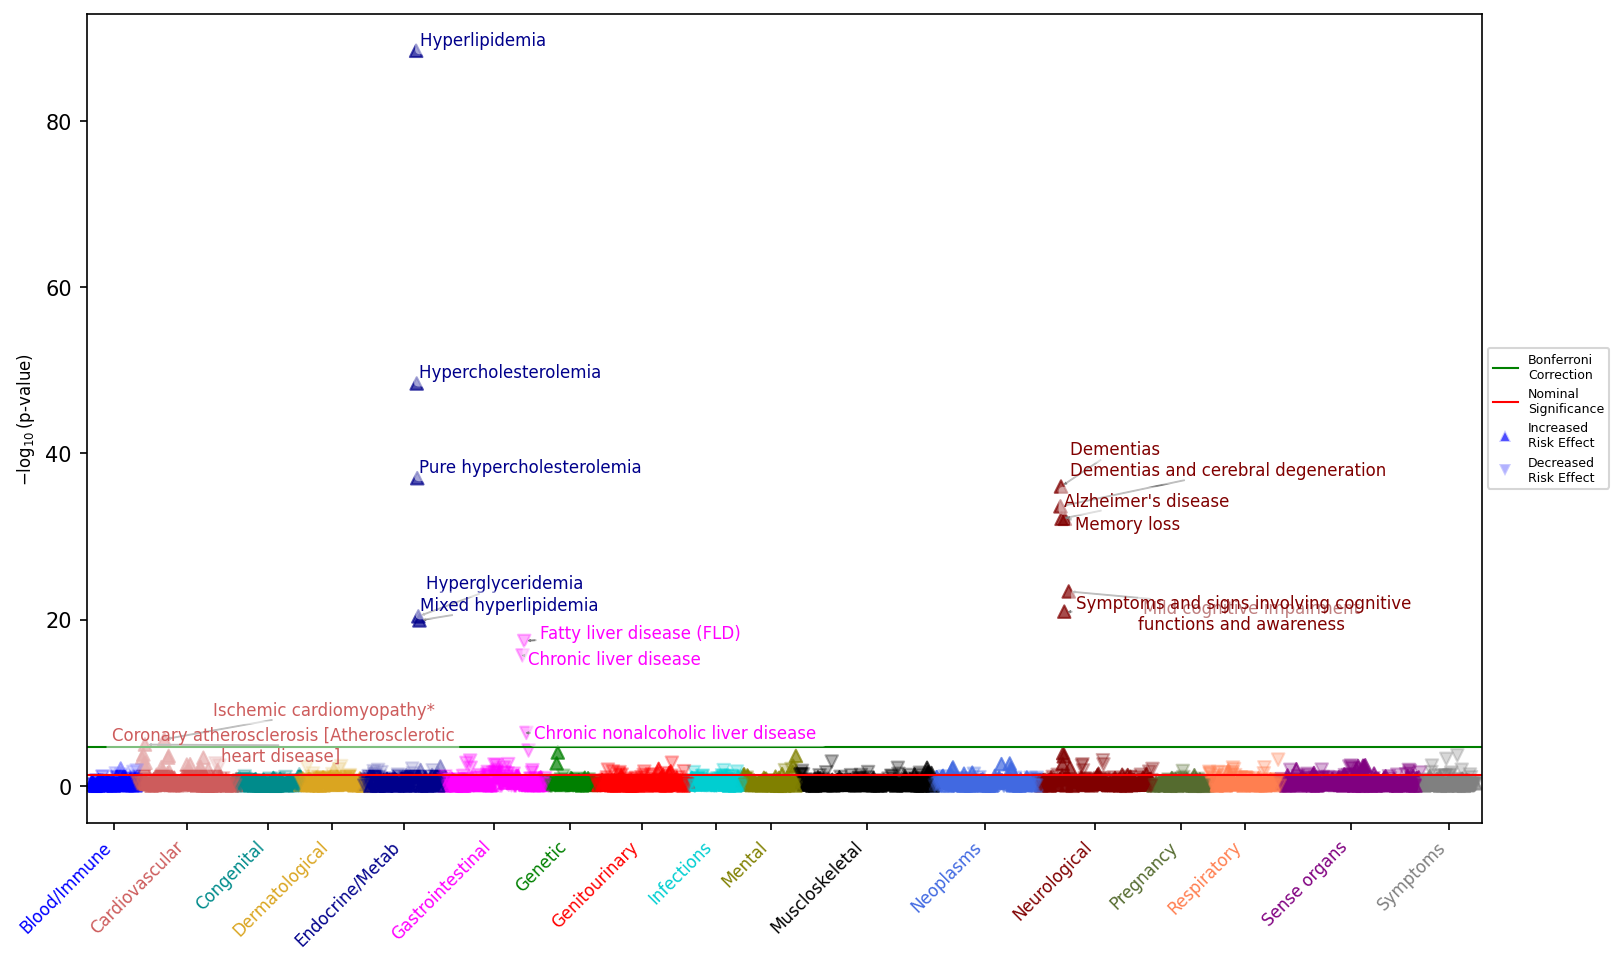

In [17]:
# generate Manhattan plot
p.manhattan(label_values="p_value", label_count=16, save_plot=False)

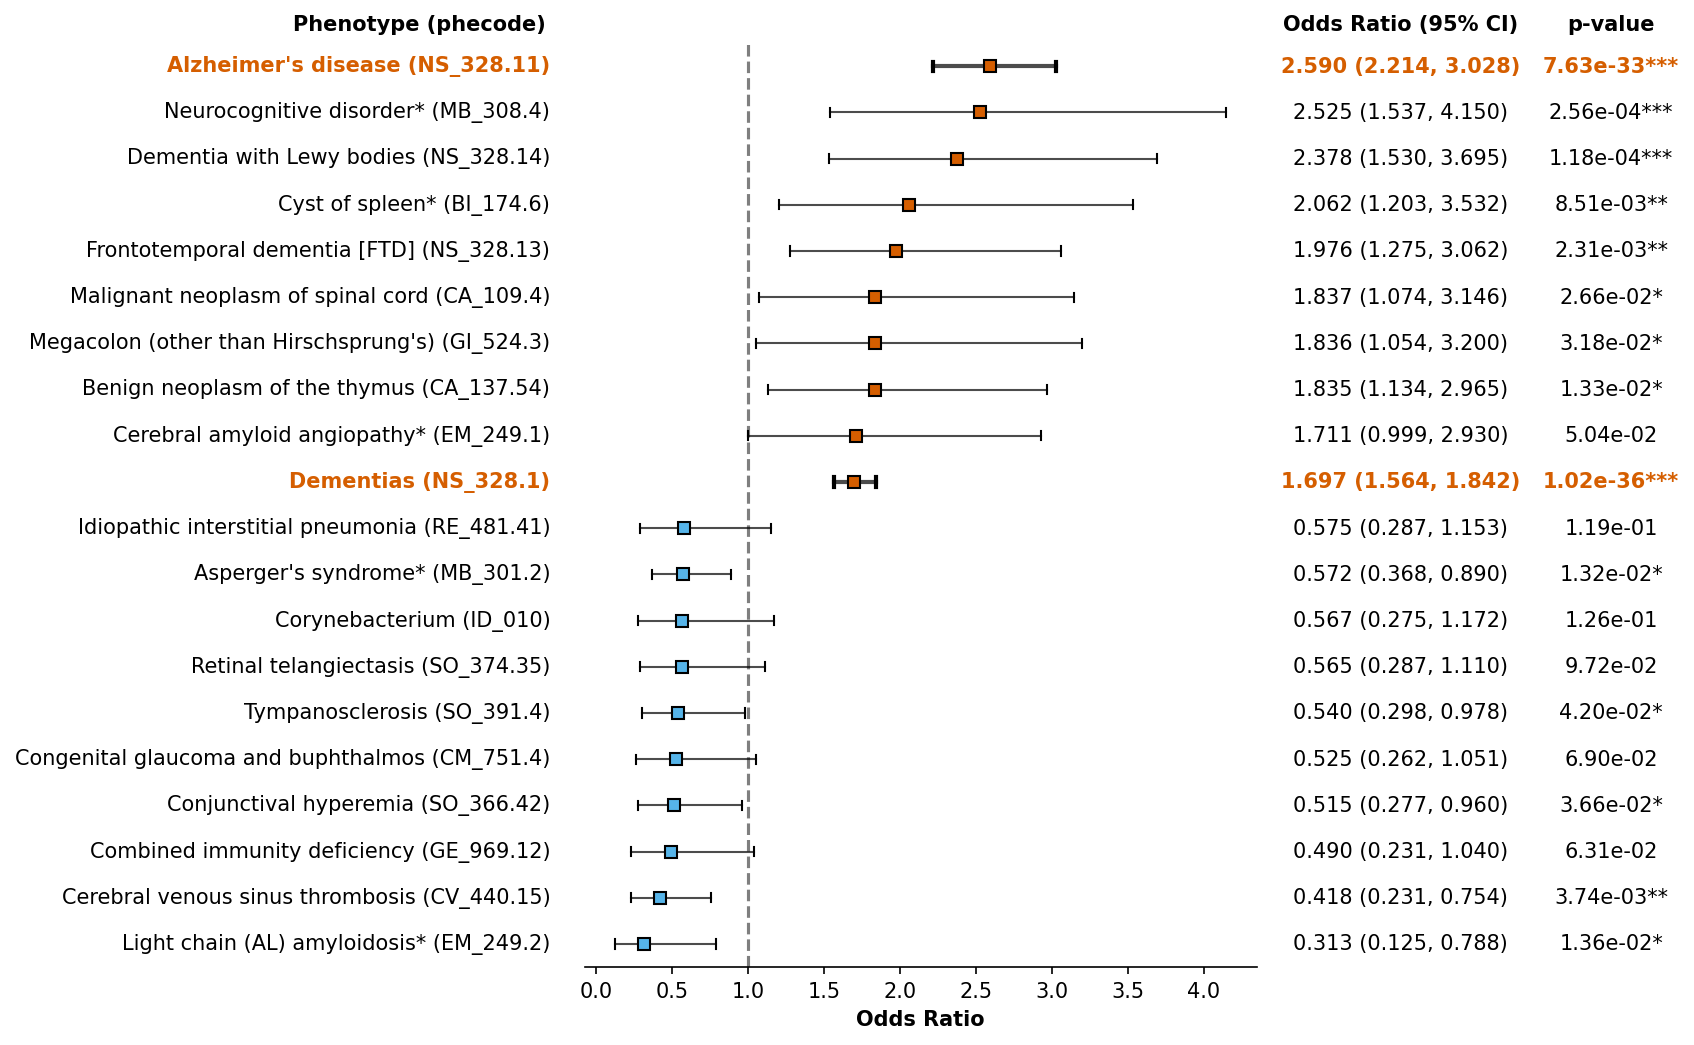

In [18]:
# generate forest plot; by default, it will show top 10 positive and negative phenotypes
p.forest(highlight_significance=True, show_p_value_asterisks=True, save_plot=False)